In [2]:

from itertools import product

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scattering.coefficients import calculate_coefficients
from scripts.fit_models import fit_regressor
from scripts.obs_realism_hst import apply_obs_realism_streaming
from scripts.obs_realism_hst import normalise

# Dataset

In [ ]:
# if you forgot to add keys to a preprocessed dataset, and save time instead of fully rerunning

# file_labels = "../datasets/tng_simulated_as_hst/labels_128x128_halfstellar32.hdf5"
# file_images = "../datasets/tng_simulated_as_hst/HST_unnormalised_128x128_halfstellar32.hdf5"
#
# with h5py.File(file_images, "a") as f_img, h5py.File(file_labels, "r") as f_lab:
#     for key in ['redshift', 'snapshot']:
#         f_img.create_dataset(key, data=f_lab[key][:])
#


In [4]:

raw_file = "../datasets/tng_simulated_as_hst/HST_unnormalised_128x128_halfstellar32.hdf5"

exposures = [1, 3, 5, 10, 15, 30]
log_scale = True
return_flux = False
output_prefix = "Noisy"

for exposure in exposures:
    apply_obs_realism_streaming(
        raw_file,
        output_prefix=output_prefix,
        exposure_time=exposure,
        chunk_size=128,
        log_scale=log_scale,
        return_flux=return_flux
    )


FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = '../dataset/tng_simulated_as_hst/Noisy-1seconds_log_ABmag_HST_128x128_halfstellar32.hdf5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 302)

In [ ]:


rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

num_images = 4
fig, axes = plt.subplots(num_images, len(exposures) + 1, figsize=(15, 3 * num_images))

with h5py.File("../datasets/tng_simulated_as_hst/HST_unnormalised_128x128_halfstellar32.hdf5", 'r') as hf:
    X_og = hf["X"][:]
    arcsecs = hf["arcsec_per_pixel"][:]
    redshift = hf["redshift"][:]
    snapshot = hf["snapshot"][:]
    stellar_mass = hf["Y_stellar_mass"][:]
    ratios = hf["Y_ratio"][:]
    time = hf["Y_time"][:]

print(redshift.min(), redshift.max(), redshift.mean(), redshift.std())
print(stellar_mass.min(), stellar_mass.max(), stellar_mass.mean(), stellar_mass.std())
print(snapshot.min(), snapshot.max(), snapshot.mean(), snapshot.std())

rng = np.random.RandomState(0)


def get_indices(target, num_images):
    quantiles = np.linspace(0, 1, 1 + num_images)
    bin_edges = np.quantile(target, quantiles)

    img_indices = []
    for i in range(len(bin_edges) - 1):
        mask = (target >= bin_edges[i]) & (target <= bin_edges[i + 1])
        candidates = np.where(mask)[0]
        if len(candidates) > 0:
            chosen = rng.choice(candidates)
            img_indices.append(chosen)
    return img_indices


img_indices = [106, 7816, 8189, 4572]
for row, img_index in enumerate(img_indices):
    original_img = X_og[img_index][0]
    arcsec = arcsecs[img_index]
    redshift_img = redshift[img_index]
    snap_img = snapshot[img_index]
    stellar_img = 10 ** stellar_mass[img_index]
    mu = ratios[img_index]
    delta_t = time[img_index]

    ax = axes[row, 0] if len(img_indices) > 1 else axes[0]
    im = ax.imshow(normalise(original_img), cmap='gray')
    # ax.set_title(f"Idealised\nR:{redshift_img:.4f}\nS:{snap_img}\nSM:{stellar_img:.4f}", fontsize=8)
    ax.set_title(rf"Idealised: $\mu={10 ** mu:.2f}$, $\Delta t={delta_t:.2f}$ (Gyr)", fontsize=8)
    ax.axis('off')

    for col, exposure in enumerate(exposures):
        file_path = (f"../datasets/tng_simulated_as_hst/{output_prefix}-{exposure}seconds"
                     f"_{'log' if log_scale else 'linear'}"
                     f"_{'flux' if return_flux else 'ABmag'}"
                     f"_HST_128x128_halfstellar32.hdf5")
        with h5py.File(file_path, 'r') as hf:
            X_noisy = hf["X"][:]

        noisy_img = X_noisy[img_index][0]
        ax = axes[row, col + 1] if len(img_indices) > 1 else axes[col + 1]
        ax.imshow(noisy_img, cmap='gray')
        ax.set_title(f"{exposure / 60:.1f} min", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()


NameError: name 'rcParams' is not defined

In [3]:
def downsample(X, y, y_stellar, other_variable=None, samples_per_bin=100):
    downsampled_X, downsampled_y, downsampled_y_stellar = [], [], []
    if other_variable is not None:
        other_variables = []

    bins = np.linspace(min(y), max(y), 10)

    for i in range(len(bins) - 1):
        lower, upper = bins[i], bins[i + 1]
        indices = (y >= lower) & (y < upper)
        selected_indices = np.where(indices)[0]

        if len(selected_indices) > samples_per_bin:
            selected_indices = np.random.choice(selected_indices, samples_per_bin, replace=False)

        downsampled_X.append(X[selected_indices])
        downsampled_y.append(y[selected_indices])
        downsampled_y_stellar.append(y_stellar[selected_indices])
        if other_variable is not None:
            other_variables.append(other_variable[selected_indices])

    if other_variable is not None:
        return np.concatenate(downsampled_X, axis=0), np.concatenate(downsampled_y, axis=0), np.concatenate(
            downsampled_y_stellar, axis=0), np.concatenate(other_variables, axis=0)
    else:
        return np.concatenate(downsampled_X, axis=0), np.concatenate(downsampled_y, axis=0), np.concatenate(
            downsampled_y_stellar, axis=0)

16086
17216


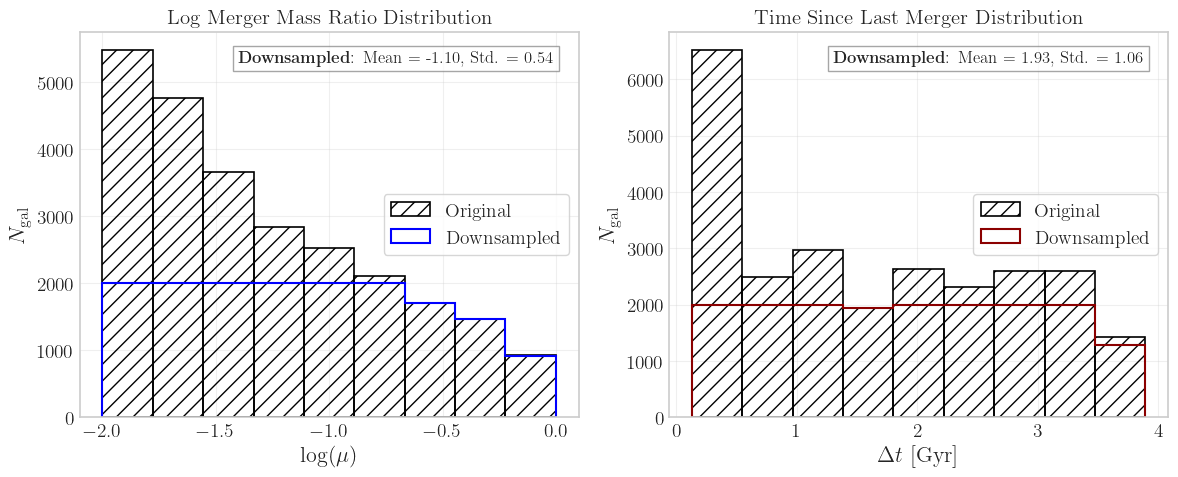

In [ ]:


with h5py.File("../datasets/tng_simulated_as_hst/HST_unnormalised_128x128_halfstellar32.hdf5", 'r') as hf:
    Y_ratio = hf["Y_ratio"][:]
    Y_time = hf["Y_time"][:]
    Y_stellar_mass = hf["Y_stellar_mass"][:]

Y_stellar_mass = np.repeat(Y_stellar_mass, 3)
Y_time = np.repeat(Y_time, 3)
Y_ratio = np.repeat(Y_ratio, 3)

X_time, y_time_down, y_time_stellar, y_ratio_correlation = downsample(np.zeros(len(Y_time)), Y_time, Y_stellar_mass,
                                                                      Y_ratio, samples_per_bin=2000)
X_ratio, y_ratio_down, y_ratio_stellar, y_time_correlation = downsample(np.zeros(len(Y_time)), Y_ratio, Y_stellar_mass,
                                                                        Y_time, samples_per_bin=2000)
print(len(y_ratio_down))
print(len(y_time_down))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins_ratio = np.linspace(min(np.min(Y_ratio), np.min(y_ratio_down)),
                         max(np.max(Y_ratio), np.max(y_ratio_down)), 10)

axes[0].hist(Y_ratio, bins=bins_ratio, edgecolor='black',
             facecolor='none', hatch='//', linewidth=1.2, label='Original')
axes[0].hist(y_ratio_down, bins=bins_ratio, histtype='step', linewidth=1.5,
             edgecolor='blue', label='Downsampled')

mean_ratio = np.mean(y_ratio_down)
std_ratio = np.std(y_ratio_down)
axes[0].text(0.95, 0.95,
             rf"\textbf{{Downsampled}}: Mean = {mean_ratio:.2f}, Std. = {std_ratio:.2f}",
             transform=axes[0].transAxes, ha='right', va='top', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

axes[0].set_xlabel(r'$\log(\mu)$', fontsize=16)
axes[0].set_ylabel(r'$N_{\mathrm{gal}}$', fontsize=16)
axes[0].set_title('Log Merger Mass Ratio Distribution', fontsize=15)
axes[0].legend()
axes[0].grid(alpha=0.3)

bins_time = np.linspace(min(np.min(Y_time), np.min(y_time_down)),
                        max(np.max(Y_time), np.max(y_time_down)), 10)

axes[1].hist(Y_time, bins=bins_time, edgecolor='black',
             facecolor='none', hatch='//', linewidth=1.2, label='Original')
axes[1].hist(y_time_down, bins=bins_time, histtype='step', linewidth=1.5,
             edgecolor='darkred', label='Downsampled')

mean_time = np.mean(y_time_down)
std_time = np.std(y_time_down)
axes[1].text(0.95, 0.95,
             rf"\textbf{{Downsampled}}: Mean = {mean_time:.2f}, Std. = {std_time:.2f}",
             transform=axes[1].transAxes, ha='right', va='top', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

axes[1].set_xlabel(r'$\Delta t$ [Gyr]', fontsize=16)
axes[1].set_ylabel(r'$N_{\mathrm{gal}}$', fontsize=16)
axes[1].set_title('Time Since Last Merger Distribution', fontsize=15)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Regression

In [4]:

def plot_graphs(real, pred, correlation_variable, mincnt=5, save_path="hexbin_true_vs_pred", ratio=True):
    rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 14,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in"
    })
    if ratio:
        correlation_text = "Mean time since last merger (Gyr)"
        label_text = r"$\mu$"
    else:
        correlation_text = "Mean log merger mass ratio"
        label_text = r"$\Delta t$ [Gyr]"

    mae = mean_absolute_error(real, pred)
    rmse = root_mean_squared_error(real, pred)

    fig, axes = plt.subplots()

    hb1 = axes.hexbin(
        real, pred,
        gridsize=20,
        cmap='viridis',
        mincnt=mincnt,
        linewidths=0.2,
        edgecolors='none'
    )
    cb1 = fig.colorbar(hb1, ax=axes)
    cb1.set_label("Point Density", fontsize=12)
    lims = [min(np.min(real), np.min(pred)), max(np.max(real), np.max(pred))]
    axes.plot(lims, lims, 'r--', label="Identity line", linewidth=1.2)
    axes.set_xlim(lims)
    axes.set_ylim(lims)
    axes.set_xlabel(f"True {label_text}", fontsize=12)
    axes.set_ylabel(f"Predicted {label_text}", fontsize=12)
    axes.legend()
    axes.grid(True, alpha=0.3)
    axes.tick_params(labelsize=10)
    axes.set_title(f"Predicted vs. True {label_text} (Density)", fontsize=13)
    cb1.ax.tick_params(labelsize=10)
    plt.tight_layout()
    plt.savefig(f"{save_path}-density.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.close()

    fig, axes = plt.subplots()
    hb2 = axes.hexbin(
        real, pred,
        C=correlation_variable,
        reduce_C_function=np.mean,
        gridsize=20,
        cmap='seismic',
        mincnt=mincnt,
        linewidths=0.2,
        edgecolors='none'
    )
    cb2 = fig.colorbar(hb2, ax=axes)
    cb2.set_label(correlation_text, fontsize=12)
    axes.plot(lims, lims, 'r--', label="Identity line", linewidth=1.2)
    axes.set_xlim(lims)
    axes.set_ylim(lims)
    axes.set_xlabel(f"True {label_text}", fontsize=12)
    axes.set_ylabel(f"Predicted {label_text}", fontsize=12)
    axes.legend()
    axes.grid(True, alpha=0.3)
    axes.tick_params(labelsize=10)

    axes.set_title(f"Predicted vs. True {label_text} (Mean Correlation)", fontsize=13)

    cb2.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.savefig(f"{save_path}-correlation.pdf", format='pdf', dpi=300, bbox_inches='tight')
    plt.close()


In [5]:

def find_lowest_factor(num, threshold):
    for i in range(threshold, num + 1):
        if num % i == 0:
            return i
    return None


def get_folds(data):
    num_folds = find_lowest_factor(data.shape[0], threshold=3)
    P = np.random.permutation(data.shape[0]).reshape((num_folds, -1))
    cross_val_folds = []

    for i_fold in range(num_folds):
        fold = (np.concatenate(P[np.arange(num_folds) != i_fold], axis=0), P[i_fold])
        cross_val_folds.append(fold)

    return cross_val_folds


from sklearn.model_selection import train_test_split, GridSearchCV


def fit_regressor(pipeline, param_grid, X, target, M, N, scattering_config, higher_config, output_name, hos=None,
                  train_size=10, seed=42, correlatory=None):
    scattering_coef, target = calculate_coefficients(
        X, target, M, N, scattering_config, higher_config, output_name, hos
    )

    if train_size is None:
        train_size = 0.8

    correlatory = np.asarray(correlatory)

    X_train, X_test, y_train, y_test, corr_train, corr_test = train_test_split(
        scattering_coef, target, correlatory,
        train_size=train_size,
        random_state=seed
    )

    cross_val_folds = get_folds(X_train)

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cross_val_folds,
        n_jobs=4,
        verbose=False,
        scoring="neg_mean_absolute_error"
    )
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    target_prediction = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, target_prediction)
    rmse = root_mean_squared_error(y_test, target_prediction)
    print(mae, rmse)

    return target_prediction, y_test, corr_test

In [6]:



n_runs = 10


def load_and_prepare_data(file_path):
    with h5py.File(file_path, 'r') as hf:
        X = hf["X"][:]
        Y_ratio = hf["Y_ratio"][:]
        Y_time = hf["Y_time"][:]
        Y_stellar_mass = hf["Y_stellar_mass"][:]

    M, N = X[0][0].shape
    X = X.reshape(len(X) * 3, M, N)
    Y_stellar_mass = np.repeat(Y_stellar_mass, 3)
    Y_time = np.repeat(Y_time, 3)
    Y_ratio = np.repeat(Y_ratio, 3)

    return X, Y_ratio, Y_time, Y_stellar_mass, M, N


def model_run(dataset, cache_path, scattering_config, higher_config, ratio=True, train_size=None, split_seeds=[42]):
    X, Y_ratio, Y_time, Y_stellar_mass, M, N = dataset

    if ratio:
        X_ratio, y_ratio_down, y_ratio_stellar, y_time_correlation = downsample(X, Y_ratio, Y_stellar_mass, Y_time,
                                                                                samples_per_bin=2000)
        data = X_ratio
        target = y_ratio_down
        correlation = y_time_correlation
    else:
        X_time, y_time_down, y_time_stellar, y_ratio_correlation = downsample(X, Y_time, Y_stellar_mass, Y_ratio,
                                                                              samples_per_bin=2000)
        data = X_time
        target = y_time_down
        correlation = y_ratio_correlation

    mae_runs = []
    rmse_runs = []

    for seed in split_seeds:
        target_prediction, y_test, y_test_correlatory = fit_regressor(
            pipeline,
            param_grid,
            data,
            target,
            M,
            N,
            scattering_config,
            higher_config,
            cache_path,
            hos="scattering",
            train_size=train_size,
            seed=seed,
            correlatory=correlation,
        )

        mae = mean_absolute_error(y_test, target_prediction)
        rmse = root_mean_squared_error(y_test, target_prediction)

        mae_runs.append(mae)
        rmse_runs.append(rmse)

        plt.hist(y_test_correlatory)
        plt.show()
        L, J, lp_norms, sigma = scattering_config["L"], scattering_config["J"], scattering_config["lp_norms"], \
            scattering_config["sigma"]
        graph_path = f"../../images/plots/{cache_path}-L{L}-J{J}-Lp{lp_norms}-sigma{sigma}-hexbin_true_vs_pred"
        plot_graphs(y_test, target_prediction, y_test_correlatory, mincnt=5, save_path=graph_path, ratio=ratio)

    # Store results
    result = {
        'exposure': exposure,
        'MAE_mean': np.mean(mae_runs),
        'MAE_std': np.std(mae_runs),
        'RMSE_mean': np.mean(rmse_runs),
        'RMSE_std': np.std(rmse_runs),
        'n_runs': n_runs
    }

    print(f"  MAE: {result['MAE_mean']:.4f} ± {result['MAE_std']:.4f}")
    print(f"  RMSE: {result['RMSE_mean']:.4f} ± {result['RMSE_std']:.4f}")

    return result

In [ ]:
param_grid = {
    "regressor__n_neighbors": [2, 3, 4, 5, 6, 7],
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor(n_neighbors=3, p=1, weights="distance")),
])

# exposures = [6480]
results = []

L = [10]
J = [6]
sigma = [0.5]
lp_norms = [[0.5, 1, 2]]
train_size = None
split_seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

print(exposures)
unnormalised_file = "../datasets/tng_simulated_as_hst/HST_unnormalised_128x128_halfstellar32.hdf5"
for l, j, sig, lp in product(L, J, sigma, lp_norms):
    print(f"l:{l}, j:{j}, sig:{sig}, lp:{lp}")
    for exposure in exposures:
        print("Exposure:", exposure)
        ratio = True
        file_path = (f"../datasets/tng_simulated_as_hst/{output_prefix}-{exposure}seconds"
                     f"_{'log' if log_scale else 'linear'}"
                     f"_{'flux' if return_flux else 'ABmag'}"
                     f"_HST_128x128_halfstellar32.hdf5")
        # file_path = "../datasets/tng_simulated_as_hst/HST_128x128_halfstellar32.hdf5"
        cache = f"LogNoisyMag{exposure}-{'ratio' if ratio else 'time'}"

        scattering_config = {
            "L": l,
            "J": j,
            "sigma": sig,
            "lp_norms": lp,
            "bispectrum": True,
            "bicoherence": True,
            "reduce": True
        }
        dataset = load_and_prepare_data(file_path)
        results.append(
            model_run(dataset, cache, scattering_config, scattering_config.copy(), ratio=ratio, train_size=train_size,
                      split_seeds=split_seeds))

results_df = pd.DataFrame(results)
output_file = "exposure-results.csv"
results_df.to_csv(output_file, index=False)


def plot_mae_vs_exposure(results_df):
    # TODO: update this plot to do SNR vs MAE
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(results_df['exposure'], results_df['MAE_mean'],
            marker='o', linewidth=2, markersize=8,
            color='blue', label='MAE')

    ax.set_xlabel('Exposure Level', fontsize=12)
    ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
    ax.set_title(f'MAE vs Exposure Level ({n_runs} runs average)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_mae_vs_exposure(results_df)

print("\nSummary Statistics:")
print(results_df[['exposure', 'MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std']])


[1, 3, 5, 10, 15, 30]
l:10, j:6, sig:0.5, lp:[0.5, 1, 2]
Exposure: 1


KeyboardInterrupt: 